# Variational Inference.

Fitting a VAE conditioned on concatenated protocol features for estimating uncertainty under each experimental condition.
In this notebook the modeled state space will be the channel features on their own, as they already appear in the annotated data, without any kind of transformation.

## Preparing the notebook.

### Libraries.

In [1]:
from collections.abc import Callable
from itertools import chain, combinations
import math
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import energy_distance
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch

from sc_exp_design.constants import DataFields, LossFields, ParamsFields
from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.networks import ConditionEncoder, MLPGaussianNoiseModel
from sc_exp_design.training.base import BaseTrainer
from sc_exp_design.training.callbacks import BaseCallBack


### Constants.

In [2]:
# working locally?
IS_RUN_LOCALLY = False

# paths
if IS_RUN_LOCALLY:
    H5AD_PATH = "/Users/lorenzo.consoli/Work/data/collab-goettgens/ds_HID01_logicle_100k_UMAP_ann.h5ad"
else:
    H5AD_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"

# obs columns
BATCH_COVARIATES = [
    'Time Stamp',
    'absolute_number_multiplier_[2^n]',
    'cell_counts',
    'count_beads',
    'counts_source_cell_phenotype',
    'cytometer',
    'cytometer_id',
    'cytometer_serial_no',
    'date',
    'days_of_culture',
    'experiment_id',
    'experiment_number',
    'hydrogel_type',
    'plate',
    'replicate',
    'source_cell_phenotype',
    'source_id',
    'total_count_beads',
    'well_id'
]
CLUSTERING_KEYS = ['batch','leiden']
EXPERIMENTAL_COVARIATES = [
    '740-yp_[µm]', 'mtg_[µm]',
    'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]',
    'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]',
    'um729_[µm]', 'scf_[ng_ml]',
    'butyzamide_[nm]', 'retinoic_acid_[µm]',
    'ldl_[ng_ml]', 'il3_[ng_ml]',
    'o2_[%]',
]
PROTOCOL_CONCAT_OBSM_KEY = "protocol_concat"
SCATTER_COVARIATES = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
TARGET_COVARIATES = ["cell_type", ]

# Tranformations
LOG1P_EXP_COL = ["um171_[nm]", "um729_[µm]", "scf_[ng_ml]", 
                 "butyzamide_[nm]", "o2_[%]",
                 "sr1_[nm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]"]
LOG21P_EXP_COL = ["ldl_[ng_ml]", 
    "il3_[ng_ml]", "retinoic_acid_[µm]",
]

# var keys
MARKER_VARS = ['marker', 'antibody']
OTHER_VARS = ['$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type']

# obsm keys
X_PCs_OBSM_KEY ='X_pca'
X_UMAP_OBSM_KEY = 'X_umap'

# validation split
VALIDATION_SIZE = 3e-1
RANDOM_SEED = 42

# model training
TRAIN_BATCH_SIZE = 256

# device
if IS_RUN_LOCALLY:
    DEVICE = "mps"
else:
    DEVICE = "cuda"


### Utility Functions and classes.

In [3]:
def get_concatenated_transformed_obs_columns(
    adata: sc.AnnData,
    column2tranform: dict[str, Callable | None],
    obsm_col="cond_concat",
):
    for column, transorm_fn in column2tranform.items():
        col_values = adata.obs[column].values[:, None]
        if isinstance(adata.obs[column].values.dtype, pd.CategoricalDtype):
            col_values = adata.obs[column].astype(float).values[:, None]
        if transorm_fn is not None:
            col_values = transorm_fn(col_values)
        adata.obsm[column] = col_values
    adata.obsm[obsm_col] = np.concatenate(
        [adata.obsm[col] for col in column2tranform.keys()], axis=-1
    )
    return adata


def my_log_prob_normal(x, params, eps=1e-15):
    # parsing parameters dict
    mean = params[ParamsFields.MEAN]
    log_std = params[ParamsFields.COVARIANCE]
    log_Z = torch.sum(log_std, dim=-1) + 0.5*x.shape[-1]*math.log(2*np.pi)
    cov=torch.exp(2*log_std)
    potential = - 0.5 * torch.sum((x - mean)**2/(cov + eps), dim=-1)
    assert torch.all(torch.isfinite(log_Z))#, logDcov
    assert torch.all(torch.isfinite(potential))
    return potential - log_Z

def log_prob_normal(
    X, # BxD
    params,
):
    mean = params[ParamsFields.MEAN]  
    log_std = params[ParamsFields.COVARIANCE]

    assert len(X.shape) == 2
    assert X.shape == mean.shape
    assert X.shape == log_std.shape
    _, D = X.shape

    log_Z = torch.sum(log_std, dim=-1) + 0.5*D*math.log(2*np.pi)
    cov = torch.exp(2*log_std)
    diff = X - mean
    log_potential = -0.5*torch.einsum("bd, bd -> b", diff, diff/cov)
    return torch.mean(log_potential - log_Z)

log_prob_normal = my_log_prob_normal

def Dkl_standard_normal(params, eps=1e-15):
    mean = params[ParamsFields.MEAN]
    log_std = params[ParamsFields.COVARIANCE]
    rv = torch.sum(1 + 2*log_std - mean**2 - torch.exp(2*log_std), dim=-1)
    assert torch.all(torch.isfinite(rv)), log_std
    return 0.5*torch.mean(rv, dim=-1)

# test
B, D = 64, 10
X = torch.zeros((B, D)).to(DEVICE)
mean = torch.zeros((B, D)).to(DEVICE)
cov = torch.zeros((B, D)).to(DEVICE)
params = {ParamsFields.MEAN:mean, ParamsFields.COVARIANCE: cov}
lkl = log_prob_normal(X,{ParamsFields.MEAN:mean, ParamsFields.COVARIANCE: cov})
print(lkl.shape)
lkl = lkl.mean(0).item()
assert np.isclose(lkl, -0.5*D*math.log(2*np.pi), atol=1e-3)
dkl = Dkl_standard_normal({ParamsFields.MEAN:mean, ParamsFields.COVARIANCE: cov})
assert np.isclose(dkl.mean().item(), 0)


class VAEModule(torch.nn.Module):
    linear_proj_config = {
        "hidden_dims":(),
        "use_dropout": False,
        "use_batchnorm": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Identity,
    }

    def __init__(
        self,
        state_dim: int,
        state_latent_dim: int,
        condition_latent_dim: int | None = 2,
        latent_dim: int | None = None,
        encoder_mlp_kwargs=None,
        decoder_mlp_kwargs=None,
        layers_before_pooling: dict | None = None,
        layers_after_pooling: dict | None = None,
        is_conditional: bool = True,
    ):
        if is_conditional:
            assert condition_latent_dim is not None
            assert layers_before_pooling is not None
            assert layers_after_pooling is not None

        super().__init__()
        self.state_dim = state_dim
        self.state_latent_dim = state_latent_dim
        self.condition_latent_dim = condition_latent_dim
        self.latent_dim = latent_dim
        self.encoder_mlp_kwargs = {} if encoder_mlp_kwargs is None else encoder_mlp_kwargs
        self.decoder_mlp_kwargs = {} if decoder_mlp_kwargs is None else decoder_mlp_kwargs
        self.layers_before_pooling = layers_before_pooling
        self.layers_after_pooling = layers_after_pooling
        self.is_conditional = is_conditional
        self.vae_modules = self._init_modules()

    def _init_modules(self):
        modules = {}
        modules["encoder"] = MLPGaussianNoiseModel(
            self.encoder_input_dim,
            self.state_latent_dim,
            latent_dim=self.state_latent_dim,
            cov_estimation_mode="anisotropic",
            encoder_mlp_kwargs=self.encoder_mlp_kwargs,
            mean_mlp_kwargs=self.linear_proj_config,
            cov_mlp_kwargs=self.linear_proj_config,
        )
        modules["decoder"] = MLPGaussianNoiseModel(
            self.decoder_input_dim,
            self.state_dim,
            latent_dim=self.state_dim,
            cov_estimation_mode="anisotropic",
            encoder_mlp_kwargs=self.encoder_mlp_kwargs,
            mean_mlp_kwargs=self.linear_proj_config,
            cov_mlp_kwargs=self.linear_proj_config,
        )
        if self.latent_dim is not None:
            modules["proj"] = torch.nn.Linear(
                self.state_dim + self.condition_latent_dim if self.is_conditional else self.state_dim,
                self.latent_dim,
            )
        if self.is_conditional:
            modules["condition_encoder"] = ConditionEncoder(
                self.condition_latent_dim,
                layers_before_pooling=self.layers_before_pooling,
                layers_after_pooling=self.layers_after_pooling,
            )
        return torch.nn.ModuleDict(modules)
    
    def get_latent_params(
        self,
        x,
        latent_condition=None,
    ):
        # handling input for encoder
        if self.is_conditional:
            assert latent_condition is not None
            encoder_input = torch.concatenate((x, latent_condition), dim=-1)
        else:
            encoder_input = x
        return self.vae_modules["encoder"](encoder_input)

    def get_decoded_params(
        self,
        latent_states,
        latent_condition=None,
    ):
        # handling input for encoder
        if self.is_conditional:
            assert latent_condition is not None
            decoder_input = torch.concatenate((latent_states, latent_condition), dim=-1)
        else:
            latent_condition = None
            decoder_input = latent_states
        if self.latent_dim is not None:
            decoder_input = self.vae_modules["proj"](decoder_input)
        return self.vae_modules["decoder"](decoder_input)

    def encode_condition(
        self,
        condition=None,
    ):
        assert condition is not None
        return self.vae_modules["condition_encoder"](condition)
    
    def sample_latent_states(
        self,
        N,
        x,
        latent_condition=None,
    ):
        # encoding states
        latent_params = self.get_latent_params(x, latent_condition=latent_condition)
        return self.sample_from_params(N, latent_params)
    
    def sample_observations(
        self,
        N,
        latent_states,
        latent_condition=None,
    ):
        # encoding states
        latent_params = self.get_decoded_params(latent_states, latent_condition=latent_condition)
        return self.sample_from_params(N, latent_params)

    def sample_prior_predictive(
        self,
        n_prior_samples,
        n_likelihood_samples,
        condition=None,
    ):
        # encoding conditions
        if self.is_conditional:
            assert condition is not None
            cond_dict = {
                k: v.type(torch.float32).to(self.device)  for k, v in condition.items()
            }
            latent_cond = self.encode_condition(cond_dict)
            latent_cond = latent_cond.unsqueeze(0)
            # print(latent_cond.shape)
        else:
            latent_cond = None
        z_prior = torch.randn((n_prior_samples, self.vae_modules["encoder"].output_dim), device=self.device, dtype=torch.float32)
        # print(z_prior.shape)
        if latent_cond is not None:
            latent_cond = latent_cond.unsqueeze(0).repeat(n_likelihood_samples, *(1 for _ in latent_cond.shape))
        x_params = self.get_decoded_params(z_prior, latent_condition=latent_cond)
        # for k, v in x_params.items():print(k, v.shape)
        x_samples = self.sample_from_params(n_likelihood_samples, x_params)
        return {
            "z_samples": z_prior,
            "x_params": x_params,
            "x_samples": x_samples,
            "latent_cond": latent_cond
        }

    def sample_posterior_predictive(
        self,
        x,
        n_posterior_samples,
        n_likelihood_samples,
        condition=None,
    ): 
        # encoding conditions 
        if self.is_conditional:
            assert condition is not None
            cond_dict = { k: v for k, v in condition.items() }
            latent_cond = self.encode_condition(cond_dict)
        else: latent_cond = None
        z_params = self.get_latent_params(x, latent_condition=latent_cond)
        z_posterior = self.sample_from_params(n_posterior_samples, z_params) # m: (N, B, Z)
        if latent_cond is not None:
            latent_cond = latent_cond.unsqueeze(0).repeat(n_posterior_samples, *(1 for _ in latent_cond.shape))
        x_params = self.get_decoded_params(z_posterior, latent_condition=latent_cond)
        x_samples = self.sample_from_params(n_likelihood_samples, x_params)
        return { "z_params": z_params, "z_samples": z_posterior, "x_params": x_params, "x_samples": x_samples, "latent_cond": latent_cond }

    @property
    def encoder_input_dim(
        self,
    ):
        if self.latent_dim is not None:
            return self.latent_dim
        if self.is_conditional:
            return self.state_dim + self.condition_latent_dim
        return self.state_dim

    @property
    def decoder_input_dim(
        self,
    ):
        if self.is_conditional:
            return self.state_latent_dim + self.condition_latent_dim
        return self.state_latent_dim

    @staticmethod
    def sample_from_params(N, params):
        # parsing parameter dictionary
        mean = params[ParamsFields.MEAN]
        std = params[ParamsFields.COVARIANCE]

        # sampling noise and matching shapes
        noise = torch.randn((N, *mean.shape), device=mean.device, dtype=torch.float)
        mean = mean.unsqueeze(0)
        cov = torch.exp(2*std.unsqueeze(0))
        return mean + torch.sqrt(cov)*noise


class VAETrainer(BaseTrainer):
    def __init__(
        self,
        model,
        optimizer: torch.optim.Optimizer,
        lr_scheduler: torch.optim.lr_scheduler.LRScheduler | None = None,
        lr_scheduler_step: Literal["grad_step", "valid_step"] = "grad_step",
        callbacks: BaseCallBack | None = None,
        grad_steps_log_interval: int | None = 1,
        num_grad_accumulation_steps: int = 20,
        reg_strength = 1e-1,
        n_mc_samples = 100,
        cond_reg_mode = None,
        cond_reg_strength=1e-1,
        eps=1e-15,
    ):
        self.model = model
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.lr_scheduler_step = lr_scheduler_step
        self.callbacks = callbacks
        self.grad_steps_log_interval = grad_steps_log_interval
        self.num_grad_accumulation_steps = num_grad_accumulation_steps 
        self.reg_strength = reg_strength
        self.n_mc_samples = n_mc_samples
        self.cond_reg_mode = cond_reg_mode
        self.cond_reg_strength = cond_reg_strength
        self.eps = eps

    def _train_step(
        self,
        step_idx: int,
        batch: dict[str, torch.Tensor],
    ):
        # parsing batch
        x = batch[DataFields.STATE_DATA] # (B, D)
        condition = batch.get(DataFields.PERTURBATION_DATA, None) # (B, C)

        # encoding condition
        if condition is not None:
            latent_cond = self.model.encode_condition(condition)
        else:
            latent_cond = None
        
        # encoder and latent regularization
        q_params = self.model.get_latent_params(x, latent_condition=latent_cond) # m: (B, Z), s_i: (B, 1), s_a: (B, Z)
        z_samples = self.model.sample_from_params(self.n_mc_samples, q_params) # m: (N, B, Z)
        dkl = Dkl_standard_normal(q_params, eps=self.eps) # ()
        reg_error = 0.5*self.reg_strength*dkl
        assert len(reg_error.shape) == 0, len(reg_error.shape)
        assert torch.all(torch.isfinite(q_params[ParamsFields.MEAN]))
        assert torch.all(torch.isfinite(q_params[ParamsFields.COVARIANCE]))
        assert torch.all(q_params[ParamsFields.COVARIANCE] + self.eps != 0)
        assert torch.isfinite(reg_error)
        assert torch.all(torch.isfinite(z_samples))
    
        # optional condition regularization
        if self.cond_reg_mode is None or latent_cond is None:
            cond_reg = 0.0
        elif self.cond_reg_mode == "l1":
            cond_reg = torch.mean(
                torch.sum(
                    torch.abs(latent_cond),
                    dim=-1
                )
            )
        elif self.cond_reg_mode == "l2":
            cond_reg =  torch.mean(
                torch.sqrt(
                    torch.sum(
                        torch.square(latent_cond),
                        dim=-1
                    )
                )
            )
        cond_rec_err = self.cond_reg_strength*cond_reg
        if isinstance(cond_reg, torch.Tensor):
            cond_reg = cond_reg.item()

        # decoder and reconstruction
        if latent_cond is not None:
            latent_cond=latent_cond.unsqueeze(0).repeat(self.n_mc_samples, *[1 for _ in z_samples.shape[1:]])
        p_params = self.model.get_decoded_params(
            z_samples,
            latent_condition=latent_cond 
        ) # m: (B, D), s_i: (B, 1), s_a: (B, D))
        # for k, v in p_params.items():
        #     print(k, v.shape)
        # print("x",x.shape)
        # log_px = log_prob_normal(x.unsqueeze(0).unsqueeze(0), p_params)
        log_px = log_prob_normal(x.unsqueeze(0), p_params)
        rec_error = torch.mean(log_px)

        assert len(rec_error.shape) == 0, len(rec_error.shape)
        assert torch.all(torch.isfinite(p_params[ParamsFields.MEAN]))
        assert torch.all(torch.isfinite(p_params[ParamsFields.COVARIANCE]))
        assert torch.all(p_params[ParamsFields.COVARIANCE] + self.eps != 0)
        assert torch.all(torch.isfinite(z_samples))
        assert torch.all(torch.isfinite(x))
        assert torch.isfinite(rec_error)

        # aggregating loss and returning it
        loss = - rec_error - reg_error + cond_rec_err
        return loss, {LossFields.LOSS: loss.item(), "dkl": -dkl.item(), "rec_error": -rec_error.item(), "cond_reg": cond_reg, "grad_step": step_idx}

    def _validation_step(
        self,
        batch: dict[str, torch.Tensor],
    ) -> tuple[torch.Tensor]:
        """"""
        # predictions, target = ..., ...
        # return predictions, target
        raise NotImplementedError


torch.Size([64])


## Data.

### Reading subsample data in `AnnData`.

In [4]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Defining tranformations for each experimental column.

In [5]:
col2transf = {}
for col in EXPERIMENTAL_COVARIATES:
    if col in LOG1P_EXP_COL:
        col2transf[col] = np.log1p
    elif col in LOG21P_EXP_COL:
        col2transf[col] = lambda x: np.log2(x + 1)
    else:
        col2transf[col] = None
print(col2transf)

{'740-yp_[µm]': None, 'mtg_[µm]': <ufunc 'log1p'>, 'rhflt3l_[ng_ml]': <ufunc 'log1p'>, 'gm-csf_[ng_ml]': <ufunc 'log1p'>, 'tpo_[ng_ml]': None, 'sr1_[nm]': <ufunc 'log1p'>, 'um171_[nm]': <ufunc 'log1p'>, 'um729_[µm]': <ufunc 'log1p'>, 'scf_[ng_ml]': <ufunc 'log1p'>, 'butyzamide_[nm]': <ufunc 'log1p'>, 'retinoic_acid_[µm]': <function <lambda> at 0x7f6801bf1440>, 'ldl_[ng_ml]': <function <lambda> at 0x7f6801bf14e0>, 'il3_[ng_ml]': <function <lambda> at 0x7f6801bf1580>, 'o2_[%]': <ufunc 'log1p'>}


### Annotating the data with utility function.

In [6]:
adata = get_concatenated_transformed_obs_columns(adata, col2transf, obsm_col=PROTOCOL_CONCAT_OBSM_KEY)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3

### Splitting train and validation data.

In [7]:
train_adata, val_adata = train_test_split(adata, test_size=VALIDATION_SIZE, random_state=RANDOM_SEED)
print("train", train_adata)
print("val", val_adata)

train View of AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', '740-yp_[µm]', 'mtg_[

### Defining data manager.

In [8]:
dm = DataManager(
    train_adata,
    perturbations=(PROTOCOL_CONCAT_OBSM_KEY, ),
    perturbations_in_obsm=(PROTOCOL_CONCAT_OBSM_KEY, ),
    perturbation_reps={PROTOCOL_CONCAT_OBSM_KEY:PROTOCOL_CONCAT_OBSM_KEY},
)

### Retrieving training and validation data.

In [9]:
train_data = dm.get_data(train_adata)
val_data = dm.get_data(val_adata)
perturbation_covariates = train_data.data.perturbation_covariates[0]
print(perturbation_covariates)

feats_protocol_concat_protocol_concat


### Defining train dataloader.

In [10]:
train_dl = SequentialDataLoader(
    train_data,
    batch_size= TRAIN_BATCH_SIZE,
    device_id=DEVICE,
)


## VAE.

###  Factory for MLP configurations.

In [11]:
get_mlp_config = lambda hidden_dims: {
    "hidden_dims": hidden_dims,
    "use_batchnorm": False,
    "use_dropout": False,
    "activation_class": torch.nn.ReLU,
    "final_activation_class": torch.nn.Identity,
}
get_lm_config = lambda: get_mlp_config(())

### Factory for Condition Encoder configurations

In [12]:
get_cond_encoder_config = lambda condition_input_dim, condition_latent_dim, hidden_dims: {
    "layers_before_pooling": {
        perturbation_covariates: 
        {
            "input_dim": condition_input_dim,
            "output_dim": condition_latent_dim,
            **get_mlp_config(
                hidden_dims
            )
        }
    },
    "layers_after_pooling": {
        "input_dim": condition_latent_dim,
        "output_dim": condition_latent_dim,
        **get_lm_config()
    }
}

### Initializing VAE.

In [13]:
state_latent_dim = 50
condition_latent_dim = 10
encoder_hidden_dims = (128, 128)
decoder_hidden_dims = (128, 128)
condition_encoder_hidden_dims = (64, 64)
condition_input_dim = len(EXPERIMENTAL_COVARIATES)
vae = VAEModule(
    state_dim=train_data.state_data.shape[-1],
    state_latent_dim=state_latent_dim,
    condition_latent_dim=condition_latent_dim,
    encoder_mlp_kwargs=get_mlp_config(decoder_hidden_dims),
    **get_cond_encoder_config(
        condition_input_dim,
        condition_latent_dim,
        condition_encoder_hidden_dims,
    ),
    is_conditional=True,
)
vae.to(DEVICE)
vae

VAEModule(
  (vae_modules): ModuleDict(
    (encoder): MLPGaussianNoiseModel(
      (model_modules): ModuleDict(
        (encoder): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=31, out_features=128, bias=True)
              (1): ReLU()
            )
            (1): Sequential(
              (0): Linear(in_features=128, out_features=128, bias=True)
              (1): ReLU()
            )
            (2): Sequential(
              (0): Linear(in_features=128, out_features=50, bias=True)
              (1): Identity()
            )
          )
        )
        (mean_net): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=50, out_features=50, bias=True)
              (1): Identity()
            )
          )
        )
        (cov_net): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=50, out_features=50, bias=True)
 

### Checking parameters.

In [14]:
# Your custom parameters (with names)
print("Custom parameters:")
for name, param in chain.from_iterable(
    [(f"{module_name}.{p_name}", p) 
     for p_name, p in module.named_parameters()]
    for module_name, module in vae.vae_modules.items()
):
    print(f"{name}: {param.shape}")

# Default PyTorch named_parameters
print("\nDefault named parameters (from vae_modules):")
for name, param in vae.vae_modules.named_parameters():
    print(f"{name}: {param.shape}")


Custom parameters:
encoder.model_modules.encoder.net.0.0.weight: torch.Size([128, 31])
encoder.model_modules.encoder.net.0.0.bias: torch.Size([128])
encoder.model_modules.encoder.net.1.0.weight: torch.Size([128, 128])
encoder.model_modules.encoder.net.1.0.bias: torch.Size([128])
encoder.model_modules.encoder.net.2.0.weight: torch.Size([50, 128])
encoder.model_modules.encoder.net.2.0.bias: torch.Size([50])
encoder.model_modules.mean_net.net.0.0.weight: torch.Size([50, 50])
encoder.model_modules.mean_net.net.0.0.bias: torch.Size([50])
encoder.model_modules.cov_net.net.0.0.weight: torch.Size([50, 50])
encoder.model_modules.cov_net.net.0.0.bias: torch.Size([50])
decoder.model_modules.encoder.net.0.0.weight: torch.Size([128, 60])
decoder.model_modules.encoder.net.0.0.bias: torch.Size([128])
decoder.model_modules.encoder.net.1.0.weight: torch.Size([128, 128])
decoder.model_modules.encoder.net.1.0.bias: torch.Size([128])
decoder.model_modules.encoder.net.2.0.weight: torch.Size([21, 128])
deco

### Defining optimizer and trainer.

In [15]:
lr = 1e-3
optimizer = torch.optim.Adam(vae.parameters(), lr=lr)
trainer = VAETrainer(
    vae,
    optimizer=optimizer,
    reg_strength = 1e-0,
    n_mc_samples = 100,
    num_grad_accumulation_steps = 20,
)

### Fitting the model.

In [16]:
num_grad_steps = 50_000
trainer.fit(
    num_grad_steps,
    train_dl,
)

Loss: -46.3055: 100%|██████████| 50000/50000 [13:39<00:00, 61.04it/s]  


### Plot loss history.

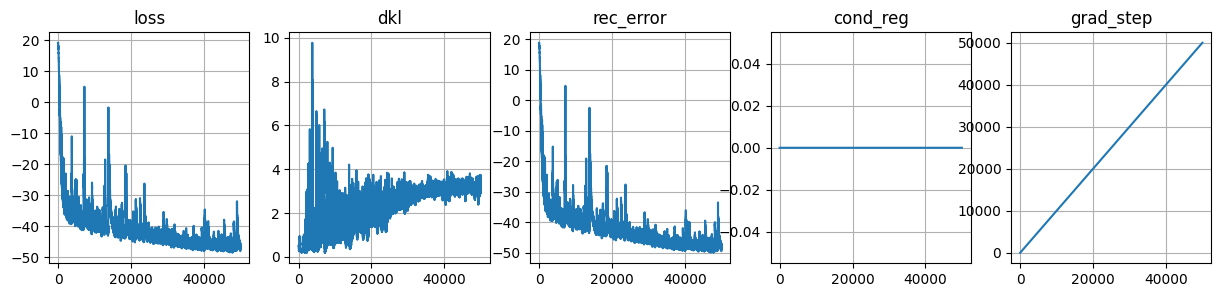

In [17]:
fig, axes = trainer.plot_training_logs(
    keys_to_plot=trainer.training_logs.keys(),
    figsize=(15, 3)
)
for ax in axes:
    ax.grid(True)
fig.show()

### Sample posterior predictive.

In [18]:
sample_post_predictive = True
if sample_post_predictive:
    n_posterior_samples = 150
    n_likelihood_samples = 1

    x = torch.from_numpy(val_data.state_data).float().to(DEVICE)
    condition = {perturbation_covariates:torch.from_numpy(val_data.perturbation_data[perturbation_covariates]).float().to(DEVICE)}

    # encoding conditions
    if vae.is_conditional:
        assert condition is not None
        latent_cond = vae.encode_condition(condition)
    else:
        latent_cond = None
    z_params = vae.get_latent_params(x, latent_condition=latent_cond)
    z_posterior = vae.sample_from_params(n_posterior_samples, z_params) # m: (N, B, Z)

    if latent_cond is not None:
        latent_cond = latent_cond.unsqueeze(0).repeat(n_posterior_samples, *(1 for _ in latent_cond.shape))
    x_params = vae.get_decoded_params(z_posterior, latent_condition=latent_cond)
    x_samples = vae.sample_from_params(n_likelihood_samples, x_params).detach().cpu().numpy()
    posterior_predicting_dict = {
        "z_params": z_params,
        "z_samples": z_posterior,
        "x_params": x_params,
        "x_samples": x_samples,
        "latent_cond": latent_cond
    }

### Visualizing generated samples.

In [19]:
x_samples = x_samples
x_mean = x_samples.mean(0)
x_var = x_samples.var(1)
x_mean.shape

(150, 30000, 21)

### Plotting samples

In [ ]:
# make sure adata.obs['cel\l_type'] exists
n_channels = adata.shape[1]
perturbation_repr = train_data.data.perturbation_covariates[0]
X_validation = val_data.state_data
E_validation = val_data.perturbation_data[perturbation_repr]
num_samples_per_protocol = 200
unique_protocols = np.unique(E_validation, axis=0)

for protocol_idx, protocol_data in enumerate(unique_protocols):
    idx_cells = (E_validation == protocol_data).all(-1)
    X_subset = val_data.state_data[idx_cells, :]
    X_subset = val_data.state_data[idx_cells, :]
    X_gen = x_mean[:, idx_cells, :]

    fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
    fig.suptitle(f"KDE plot of channel features: {protocol_idx}", fontsize=16)
    for i in range(n_channels):
        sns.kdeplot(X_subset[:, i], ax=ax[i], color="green", label="Real")
        sns.kdeplot(X_gen[:, i], ax=ax[i], color="red", label="Generated")
        ax[i].grid(True)
        ax[i].set_title(adata.var_names[i])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()